<center><span style="font-size:40px;"><b>NUTS vs HMC on GERMAN CREDIT CARD POSTERIOR</b></span></center>

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt   # backend symbolic math (used inside PyMC models)

import matplotlib.pyplot as plt
import time

from ucimlrepo import fetch_ucirepo # to load datasets from the UCI ML Repository

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

In [2]:
#!pip3 install -U ucimlrepo 

---

---

---

# THE CONTEXT

We are working with the Statlog (German Credit Data) dataset, which is a classic classification problem. Each row represents a customer, described by a set of attributes, and the goal is to decide whether that customer is a good or bad credit risk.

The dataset contains 1000 individuals and 20 features. These features are a mix of numerical variables (such as age, credit amount, duration) and categorical variables (encoded as symbols like A11, A34, etc.). The categorical variables represent things like employment status, credit history, housing situation, and so on.

The target variable $y$ is the credit class:
- $y = 1$ means good credit
- $y = 2$ means bad credit

So overall, we are dealing with a supervised binary classification problem, but we will approach it from a Bayesian perspective.

The matrix $X$ contains all the input features. As said, each row is a customer, and each column is an attribute. Many of these attributes are categorical and currently represented as symbolic codes (e.g. A11, A43). These are not directly usable in a regression model, so they will need preprocessing.

The vector $y$ contains the labels. Right now it takes values in $\{1, 2\}$ (but for modeling we will convert it into $\{-1, +1\}$).

Our goal is Bayesian inference. We want to reproduce (and study) a Bayesian logistic regression model, and then compare two sampling algorithms: HMC and NUTS.

Conceptually, we assume that the probability of a customer being "good" (this is the likelihood) depends on a linear combination of the features:
$$
p(y_i = 1 \mid x_i, \alpha, \beta) = \sigma(\alpha + x_i \cdot \beta)
$$
where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the logistic function.

From a Bayesian perspective, we place priors on the parameters:
$$
\alpha \sim \mathcal{N}(0, \sigma^2), \quad \beta_j \sim \mathcal{N}(0, \sigma^2)
$$
with $\sigma^2 = 100$, a very wide (and so weak) prior.

Given the data, we infer their posterior distribution:
$$
p(\alpha, \beta \mid X, y) \propto p(y|X, \alpha, \beta) \, p(\alpha) \, p(\beta)
$$

This is the posterior we will sample from using pyMC.

But before defining the model, we need to preprocess the data properly:
* Categorical variables must be converted into numerical form. This is typically done via one-hot encoding, turning each category into binary indicator variables.
* Numerical features should be normalized so that they have comparable scale (zero mean, unit variance). This is important for HMC and NUTS, since their efficiency depends strongly on the geometry of the posterior.
* The target variable $y$ should be transformed into a consistent format (for example $\{-1,1\}$ for Bernoulli likelihood).

Once preprocessing is done, we will:
- define the Bayesian logistic regression model in PyMC
- sample from the posterior using:
  - Hamiltonian Monte Carlo (HMC)
  - No-U-Turn Sampler (NUTS)
- compare their performance using diagnostics such as:
  - effective sample size (ESS)
  - autocorrelation
  - convergence (R-hat)
  - computational cost

The main goal is to understand how HMC and NUTS behave on a real, moderately complex posterior, not anymore just a synthetic Gaussian example.

---

---

---

# DATA UPLOAD (ORIGNAL VERSION)

This version of the dataset has categorical data in some columns.

In [3]:
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 

In [4]:
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features   # X: predictors (features)
y = statlog_german_credit_data.data.targets    # y: labels (credit approval / denial)

In [5]:
# metadata 
# print(statlog_german_credit_data.metadata)     # metadata: general info (source, description, etc.)

In [6]:
# variable information 
display(statlog_german_credit_data.variables)  # variables: schema of dataset (feature names, types)

,name,role,type,demographic,description,units,missing_values
0,Attribute1,Feature,Categorical,NaN,Status of existing checking account,NaN,no
1,Attribute2,Feature,Integer,NaN,Duration,months,no
2,Attribute3,Feature,Categorical,NaN,Credit history,NaN,no
3,Attribute4,Feature,Categorical,NaN,Purpose,NaN,no
4,Attribute5,Feature,Integer,NaN,Credit amount,NaN,no
5,Attribute6,Feature,Categorical,NaN,Savings account/bonds,NaN,no
6,Attribute7,Feature,Categorical,Other,Present employment since,NaN,no
7,Attribute8,Feature,Integer,NaN,Installment rate in percentage of disposable i...,NaN,no
8,Attribute9,Feature,Categorical,Marital Status,Personal status and sex,NaN,no
9,Attribute10,Feature,Categorical,NaN,Other debtors / guarantors,NaN,no


In [7]:
X

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,4,A121,31,A143,A152,1,A172,1,A191,A201
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,4,A122,40,A143,A152,1,A174,1,A192,A201
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,4,A124,23,A143,A153,1,A173,1,A192,A201


In [8]:
# X.dtypes

In [9]:
print(X['Attribute7'].value_counts())

Attribute7
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64


All values appearing in the categorical columns are like `Ai4` with *i* being the column number.

In [10]:
y
# y = 2*y - 3   # to change from {1,2} to {-1, +1}

,class
0,1
1,2
2,1
3,1
4,2
...,...
995,1
996,1
997,1
998,2


---

---

---

# DATA UPLOAD (NUMERICAL VERSION)

This is the version with all numerical columns, and  also the one used in the No U Turn paper.

In [2]:
# URL to the numeric file o the UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"

# Il file non ha header e usa spazi bianchi come separatore
df = pd.read_csv(url, sep='\s+', header=None)

# The last column is the target (1 = Good, 2 = Bad)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_23086/3352265122.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep='\s+', header=None)


In [3]:
X

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,6,4,12,5,5,3,4,1,67,...,1,0,0,1,0,0,1,0,0,1
1,2,48,2,60,1,3,2,2,1,22,...,1,0,0,1,0,0,1,0,0,1
2,4,12,4,21,1,4,3,3,1,49,...,1,0,0,1,0,0,1,0,1,0
3,1,42,2,79,1,4,3,4,2,45,...,1,0,0,0,0,0,0,0,0,1
4,1,24,3,49,1,3,3,4,4,53,...,1,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4,12,2,17,1,4,2,4,1,31,...,1,0,0,1,0,0,1,0,1,0
996,1,30,2,39,1,3,1,4,2,40,...,1,0,1,1,0,0,1,0,0,0
997,4,12,2,8,1,5,3,4,3,38,...,1,0,0,1,0,0,1,0,0,1
998,1,45,2,18,1,3,3,4,4,23,...,1,0,0,1,0,0,0,0,0,1


In [4]:
y

0      1
1      2
2      1
3      1
4      2
      ..
995    1
996    1
997    1
998    2
999    1
Name: 24, Length: 1000, dtype: int64

### NORMALIZATION

In [5]:
# Normalization: zero mean and unit variance
X = (X - X.mean())/X.std()
display(X)

# Target change from {1,2} to {-1, +1}
y = 2*y - 3
display(y)

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,-1.253938,-1.235859,1.343342,-0.733065,1.832252,1.337409,0.449102,1.046463,-1.293076,2.765073,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
1,-0.458797,2.247070,-0.503176,0.965893,-0.699357,-0.317800,-0.963168,-0.765594,-1.293076,-1.190808,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
2,1.131486,-0.738298,1.343342,-0.414510,-0.699357,0.509805,0.449102,0.140434,-1.293076,1.182721,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,1.99900,-1.304224
3,-1.253938,1.749509,-0.503176,1.638398,-0.699357,0.509805,0.449102,1.046463,-0.340885,0.831087,...,-0.195916,-0.552429,-0.338692,-3.121368,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973
4,-1.253938,0.256825,0.420083,0.576549,-0.699357,-0.317800,0.449102,1.046463,1.563498,1.534354,...,-0.195916,1.808378,-0.338692,0.320052,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.131486,-0.738298,-0.503176,-0.556090,-0.699357,0.509805,-0.963168,1.046463,-1.293076,-0.399632,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,1.99900,-1.304224
996,-1.253938,0.754386,-0.503176,0.222599,-0.699357,-0.317800,-2.375438,1.046463,-0.340885,0.391544,...,-0.195916,-0.552429,2.949581,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,-1.304224
997,1.131486,-0.738298,-0.503176,-0.874645,-0.699357,1.337409,0.449102,1.046463,0.611307,0.215727,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
998,-1.253938,1.998289,-0.503176,-0.520695,-0.699357,-0.317800,0.449102,1.046463,1.563498,-1.102900,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973


0     -1
1      1
2     -1
3     -1
4      1
      ..
995   -1
996   -1
997   -1
998    1
999   -1
Name: 24, Length: 1000, dtype: int64

### MODEL

The target distribution is $p(\alpha, \beta \mid X, y) \propto p(y|X, \alpha, \beta) \, p(\alpha) \, p(\beta)$, so:

$$
p(\alpha, \beta \mid X, y) \propto
\exp\left(
-\sum_{i}\log\!\left(1+\exp\!\left\{-y_i\left(\alpha + x_i \cdot \beta\right)\right\}\right)
-\frac{\alpha^2}{2\sigma^2}
-\frac{1}{2\sigma^2}\,\beta \cdot \beta
\right)
$$



In [6]:
# "α and each element of β are given weak zero-mean normal priors with variance σ^2 = 100"
prior_mean = 0
prior_var = 100

TARGET_ACCEPT = 0.9
CHAINS = 4

In [7]:
with pm.Model() as model:
    X_data = pm.Data( "X", X )
    y_data = pm.Data( "y", y )

    # Priors
    alpha = pm.Normal( "alpha", mu=0.0, sigma=np.sqrt(prior_var) )
    beta  = pm.Normal( "beta",  mu=0.0, sigma=np.sqrt(prior_var), shape=X_data.shape[1] )

    # eta_i = alpha + x_i * beta
    eta = alpha + pt.dot( X_data, beta )

    # log-likelihood: -sum_i log(1 + exp(-y_i * eta_i))
    # log1p is log(1+...) and is more numerically stable
    loglike = -pt.sum( pt.log1p( pt.exp( -y_data * eta ) ) ) # maybe better: loglike = -pt.sum(pt.nnet.softplus(-y_data * eta))
    pm.Potential("likelihood", loglike)

    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=2026,
        progressbar = True,
        nuts_sampler = "pymc"
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [8]:
summary_nuts = az.summary(idata, var_names=["alpha", "beta"], round_to=3)
display(summary_nuts)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.218,0.093,-1.394,-1.044,0.001,0.001,6172.038,3199.686,1.001
beta[0],-0.746,0.092,-0.911,-0.570,0.001,0.001,7107.801,3353.072,1.002
beta[1],0.426,0.104,0.216,0.611,0.001,0.002,6245.826,3446.752,1.001
beta[2],-0.420,0.095,-0.598,-0.242,0.001,0.001,4895.050,3164.292,1.001
beta[3],0.126,0.108,-0.071,0.327,0.001,0.002,5884.934,3114.790,1.001
beta[4],-0.370,0.095,-0.555,-0.198,0.001,0.002,7064.624,2950.805,1.000
beta[5],-0.181,0.092,-0.348,-0.001,0.001,0.001,6412.520,3455.023,1.000
beta[6],-0.154,0.084,-0.311,-0.002,0.001,0.002,7404.699,2853.551,1.000
beta[7],0.013,0.091,-0.150,0.191,0.001,0.001,7116.921,2983.005,1.002
beta[8],0.183,0.104,-0.009,0.383,0.001,0.002,5999.539,3048.681,1.002


Number of parameters with R_hat > 1.05: 0


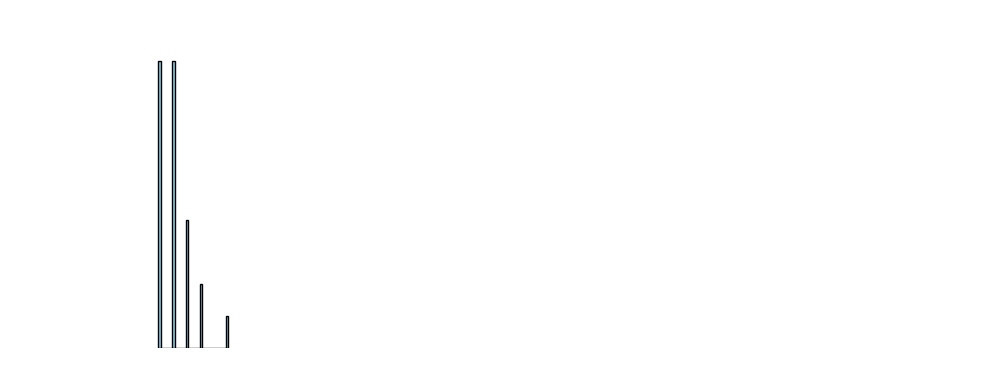

Number of parameters with ESS_bulk < 400: 0
Number of divergences: 0


In [9]:
# 1) Count how many rows exceed R_hat > 1.05
rhat_exceed = (summary_nuts['r_hat'] > 1.05).sum()
print(f"Number of parameters with R_hat > 1.05: {rhat_exceed}")

# 2) Plot the distribution of R_hat
plt.figure(figsize=(12, 4))
plt.hist(summary_nuts['r_hat'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(1.05, color='red', linestyle='--', label='Threshold (1.05)')
plt.title('Distribution of R_hat values')
plt.xlabel('R_hat')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 3) Check ESS (Effective Sample Size)
# Generally, we look at 'ess_bulk' or 'ess_tail'
# A common rule of thumb is ESS > 100 * number of chains (e.g., 400)
ess_threshold = 400
low_ess = (summary_nuts['ess_bulk'] < ess_threshold).sum()
print(f"Number of parameters with ESS_bulk < {ess_threshold}: {low_ess}")

# Optional: Display parameters that failed the checks
if rhat_exceed > 0:
    print("\nParameters with R_hat > 1.05:")
    print(summary_nuts[summary_nuts['r_hat'] > 1.05])

print("Number of divergences:", int(idata.sample_stats["diverging"].sum()))

In [10]:
az.plot_pair(idata, var_names=["beta"], kind="kde", marginals=True)

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='beta\n0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='beta\n0', ylabel='beta\n7'>,
        <Axes: xlabel='beta\n1'>, <Axes: xlabel='beta\n2'>,
        <Axes: xlabel='beta\n3'>, <Axes: xlabel='beta\n4'>,
        <Axes: xlabel='beta\n5'>, <Ax

---

### ACCEPTANCE RATE ANALYSIS

NUTS internally tune the step size so that the average acceptance probability is close to a target value 
$\delta=\textit{TARGET\_ACCEPT}$

We now check if the sampler actually reached this target and how much uncertainty do we have on that estimate.

In [11]:
idata.sample_stats["acceptance_rate"]

<xarray.DataArray 'acceptance_rate' (chain: 4, draw: 1000)> Size: 32kB
array([[0.93798302, 0.98216588, 0.92194481, ..., 0.87687798, 0.98111191,
        0.99116195],
       [0.85328748, 0.95744698, 0.95566457, ..., 0.65391955, 0.9606991 ,
        0.98615957],
       [0.96941111, 0.99850036, 0.99861264, ..., 0.9152949 , 0.95226829,
        0.81432687],
       [1.        , 0.76483135, 0.94541804, ..., 0.98856657, 0.91869866,
        0.91205292]], shape=(4, 1000))
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

When we run HMC or NUTS, to obtain the mean acceptance rate we could compute:
$$
\mu_a = \frac{1}{N} \sum_{i=1}^N a_i
$$
where $a_i$ is the acceptance probability at iteration $i$.

But our samples are *correlated*, so $\mu_a$ is not as precise as it would be with independent samples. We want to know how much uncertainty is there in this estimate. That is the **Monte Carlo Standard Error (MCSE)**.

Instead of treating all samples as independent (wrong), we split the chain into *batches*, compute the *mean inside each batch* and treat those batch means as approximately independent. Then compute the variance across batches.

In [12]:
# Monte Carlo Standard Error (MCSE) on realized mean acceptance rate
def mcse_batch_means(x, batch_size=None, min_batches=20):
    """
    We split the sinle input chain into m batches
    Compute the mean of each batch
    Treats those batch means as approximately independent
    Estimates variance from them
    """
    x = np.asarray(x, dtype=float).ravel()   # now this is a 1D array
    n = x.size                               # number of samples
    
    if batch_size is None:
        batch_size = int(np.sqrt(n))
    batch_size = max(1, int(batch_size))
    m = n // batch_size                      # m = number of batches
    
    if m < min_batches:   
        batch_size = max(1, n // min_batches) # ensures at least min_batches (default 20)
        m = n // batch_size
        
    if m < 2:  # safety check
        raise ValueError(f"Not enough data: n={n}, batch_size={batch_size}, batches={m}")

    # discards leftover samples so reshape works cleanly
    n_used = m * batch_size
    x_used = x[:n_used]
    
    # BATCH MEANS:
    batch_means = x_used.reshape(m, batch_size).mean(axis=1)   # we obtain m means
    mcse = batch_means.std(ddof=1) / np.sqrt(m)                # computes mcse with independent approx
    
    return mcse

In [13]:
acceptance = idata.sample_stats["acceptance_rate"].to_numpy()    # Extract acceptance rates with shape: (chains, draws)
h_chain = acceptance.mean(axis=1)              # mean acceptance for each chain. shape = (chains)
diff_chain = h_chain - TARGET_ACCEPT           # how far each chain is from target
print(f"min/max h: {h_chain.min():.4f} / {h_chain.max():.4f}")   # sanity check

min/max h: 0.8953 / 0.9062


In [14]:
mcse = np.zeros(CHAINS)            # initialization
z = 1.96                           # ~95% normal quantile

for c in range(CHAINS):            # loop over chains
    h = acceptance[c].mean()       # mean acceptance for the chain
    diff = h - TARGET_ACCEPT       # how far the chain is from target
    mcse[c] = mcse_batch_means(acceptance[c])     # computes mcse for the chain
    ci95 = (diff - z*mcse[c], diff + z*mcse[c])   # cofidence interval at 95%
    print(f"chain {c}: h={h:.4f}, diff={diff:+.4f}, mcse={mcse[c]:.4f}, CI95(diff)=[{ci95[0]:.4f} : {ci95[1]:.4f}] Zero inside: {ci95[0]*ci95[1]<0}")
    

chain 0: h=0.9062, diff=+0.0062, mcse=0.0025, CI95(diff)=[0.0013 : 0.0110] Zero inside: False
chain 1: h=0.9027, diff=+0.0027, mcse=0.0028, CI95(diff)=[-0.0029 : 0.0082] Zero inside: True
chain 2: h=0.8953, diff=-0.0047, mcse=0.0026, CI95(diff)=[-0.0098 : 0.0005] Zero inside: True
chain 3: h=0.9048, diff=+0.0048, mcse=0.0023, CI95(diff)=[0.0004 : 0.0092] Zero inside: False


The output above prints:
* `True` → target achieved (within noise)
* `False` → systematic deviation

In [15]:
# NOW ALL CHAINS TOGETHER
h_pooled = acceptance.mean()              # overall acceptance mean
diff_pooled = h_pooled - TARGET_ACCEPT    # difference from target
mcse_pooled = mcse_batch_means(acceptance.reshape(-1))  # flatten everything: treat as one long chain
ci95_pooled = (diff_pooled - 1.96*mcse_pooled, diff_pooled + 1.96*mcse_pooled)  
print("pooled:", f" h = {h_pooled:.4f}, diff = {diff_pooled:.4f}, CI95(diff)=[{ci95_pooled[0]:.4f} : {ci95_pooled[1]:.4f}] Zero inside: {ci95_pooled[0]*ci95_pooled[1]<0}")


pooled:  h = 0.9022, diff = 0.0022, CI95(diff)=[-0.0001 : 0.0045] Zero inside: True


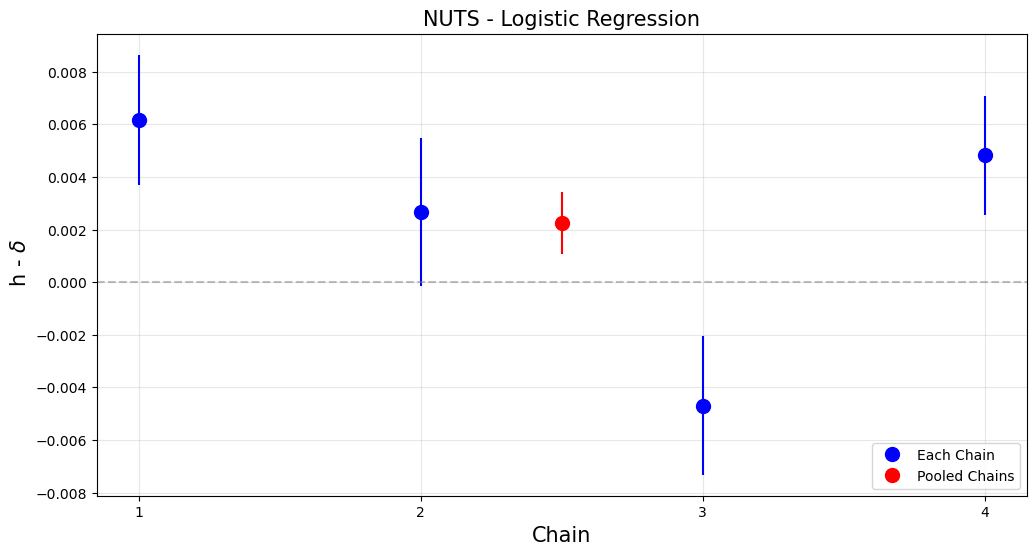

In [16]:
# plot with errorbars
fig, ax = plt.subplots(figsize=(12,6))
plt.errorbar(x = np.arange(1, CHAINS+1, 1), y = diff_chain, yerr = mcse, ls="", fmt="o", ms=10, label="Each Chain", color="blue" )
plt.errorbar(x = (CHAINS+1)/2, y = diff_pooled, yerr = mcse_pooled, ls="", fmt="o", ms=10, label="Pooled Chains", color = "red" )
plt.xlabel("Chain", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.xticks(np.arange(1, CHAINS+1, 1))
plt.legend(loc="lower right", fontsize=10)
plt.axhline(y=0.0, ls="--", color="gray", alpha=0.5)
plt.grid(alpha=0.3)
plt.show()

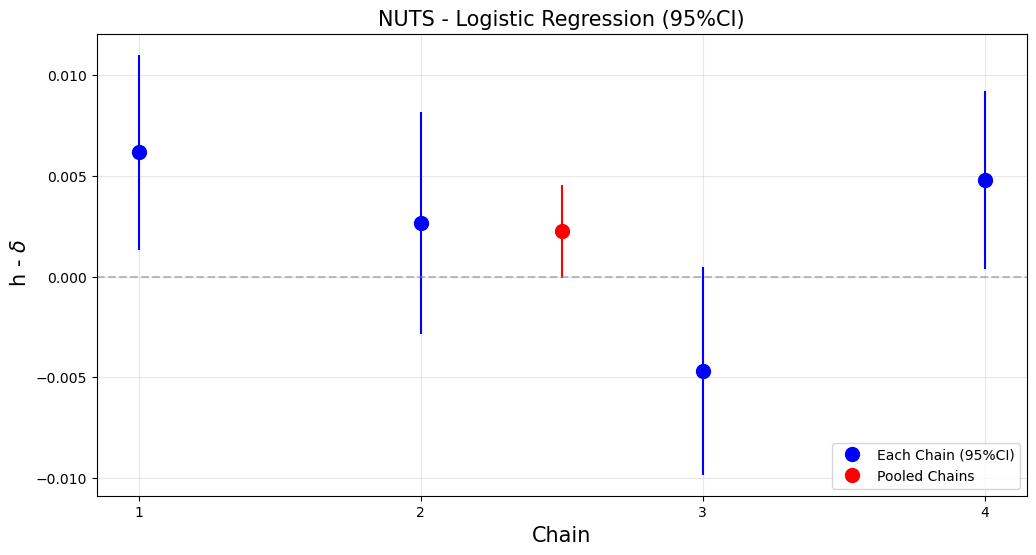

In [17]:
# plot with errorbars
fig, ax = plt.subplots(figsize=(12,6))
plt.errorbar(x = np.arange(1, CHAINS+1, 1), y = diff_chain, yerr = 1.96 * mcse, ls="", fmt="o", ms=10, label="Each Chain (95%CI)", color="blue" )
plt.errorbar(x = (CHAINS+1)/2, y = diff_pooled, yerr = 1.96 * mcse_pooled, ls="", fmt="o", ms=10, label="Pooled Chains", color = "red" )
plt.xlabel("Chain", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Logistic Regression (95%CI)", fontsize=15)
plt.xticks(np.arange(1, CHAINS+1, 1))
plt.legend(loc="lower right", fontsize=10)
plt.axhline(y=0.0, ls="--", color="gray", alpha=0.5)
plt.grid(alpha=0.3)
plt.show()

Above we are checking:
$$
h - \delta \approx 0 \ ?
$$

where:
* $h$ = realized acceptance
* $\delta$ = target_accept

NUTS uses *dual averaging* to tune step size $\epsilon$, so our goal is to achieve a target acceptance rate. So this code is basically verifying if the dual averaging adaptation converged properly.

Conceptually, we are validating:
$$
\mathbb{E}[a_t] \approx \delta
$$

---

# TARGET ACCEPTANCE RATE ANALYSIS

We want to study how the **target acceptance rate** affects the efficiency of NUTS.

In HMC/NUTS, there is a key tradeoff:
* *low acceptance rate* → large step size → cheap trajectories but inaccurate
* *high acceptance rate* → small step size → accurate but expensive

So the question is: what value of target acceptance gives the best efficiency?

During tuning, $\epsilon$ is adapted so that $\mathbb{E}[\text{acceptance rate}] \approx \delta$ where $\delta$ = `target_accept`. So by varying `target_accept`, you are indirectly changing $ \epsilon \Rightarrow \text{trajectory length, accuracy, cost} $.

### APPROACH

We are looping over many $\delta$ values: $ \delta \in [0.20, 0.98]$.

For each value:

1. run NUTS
2. measure what actually happens
3. evaluate efficiency

So we compute:
1. Acceptance rate:
$$
h_c = \frac{1}{T} \sum_t a_{c,t}
\quad \text{and} \quad
h_c - \delta
$$

2. *Effective Sample Size (ESS)*, which measures statistical efficiency for $\alpha$ (scalar) plus $\beta$ (vector, 24 dims):
$$
\text{ESS} \approx \frac{N}{1 + 2\sum_k \rho_k}
$$
But ESS alone is not enough. Different runs have different computational costs. In HMC/NUTS $\text{cost} \propto \text{\# gradient evaluations}$, where each leapfrog step = 1 gradient evaluation.\
So the key metric is **ESS per gradient evaluation (unit of computation)**, and we compute:
$$
\frac{\text{ESS}}{\text{\# gradient evaluations}}
$$
This is the right metric because:
    * small $\epsilon$ (high acceptance) $\Rightarrow $ high ESS (good mixing) but many steps → expensive
    * large $\epsilon$ (low acceptance) $\Rightarrow $ cheap steps but poor mixing → low ESS

    So the tradeoff is $\text{efficiency} = \frac{\text{ESS}}{\text{cost}}$


Then:
* average (or take minimum, more conservative) over chains
* average (or take minimum, more conservative) over parameters
to get a single scalar efficiency measure for each $\delta$ value.

---

### RESULTS

We will end up with:
* x-axis: target acceptance $\delta$
* y-axis: efficiency (ESS per gradient)

And we want to see where is the maximum. From theory (and the NUTS paper) optimal $\delta$ is typically around $ 0.6 \text{ to } 0.9 $. We should see a peak in efficiency.

In [56]:
# In function of the target acceptance:
prior_mean = 0                              # Mean of the Gaussian prior for parameters
prior_var = 100                             # Variance of the Gaussian prior

CHAINS = 4                                  # Number of MCMC chains to run in parallel
accept_rate_list = np.arange(0.20, 0.99, 0.02)  # Range of target acceptance rates to explore
all_diffs = np.zeros(shape=(len(accept_rate_list), CHAINS))  # Store (h - target_accept) for each chain and each setting
all_mcse = np.zeros_like(all_diffs)         # Store MCSE of acceptance rate estimates for each chain and setting

ESS_GRAD_EV_ALPHA = []                      # Store ESS per gradient evaluation for alpha (per experiment)
ESS_GRAD_EV_BETA = []                       # Store ESS per gradient evaluation for beta (per experiment)
ESS_GRAD_EV_SCALAR = []                     # Store a single aggregated efficiency metric per experiment

# choose if using the mean or the min for the ESS:
choice = "min"


In [57]:
# ======================= MODEL =================
with pm.Model() as model:  
    X_data = pm.Data("X", X)  # Register feature matrix X as shared data inside the model
    y_data = pm.Data("y", y) 
    # Priors
    alpha = pm.Normal("alpha", mu=0.0, sigma=np.sqrt(prior_var))  # Prior for intercept alpha ~ N(0, prior_var)
    beta  = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=X_data.shape[1])  # Prior for coefficients beta_j ~ N(0, prior_var)

    # eta_i = alpha + x_i * beta
    eta = alpha + pt.dot(X_data, beta)  # Linear predictor: eta = alpha + X @ beta

    # log-likelihood: -sum_i log(1 + exp(-y_i * eta_i))
    # log1p is log(1+...) and is more numerically stable
    loglike = -pt.sum(pt.log1p(pt.exp(-y_data * eta)))  # Compute total log-likelihood using logistic regression formulation

    pm.Potential("likelihood", loglike)  # Add custom log-likelihood term to the model

    # =========== loop over different target acceptance values δ ===========================
    print(f"Iteration progress:")
    for i, target_accept in enumerate(accept_rate_list): 
        
        print(f"{i+1}/{len(accept_rate_list)}", end="    ") 
        
        idata = pm.sample(  
            draws=1000,     # number of posterior samples (after warmup)
            tune=1000,      # number of warmup steps
            chains=CHAINS, 
            target_accept=target_accept,
            random_seed=2026+i,     # different seed for each run
            progressbar = False,    # disable progress bar
            quiet = True,           # suppress sampler messages
            nuts_sampler = "pymc",  # use PyMC's NUTS implementation        
        )
    
        acceptance = idata.sample_stats["acceptance_rate"].to_numpy()  # extract acceptance rates (chains, draws)
        h_chain = acceptance.mean(axis=1)     # mean acceptance per chain
        diff_chain = h_chain - target_accept  # deviation from target δ per chain
        mcse = np.zeros(CHAINS)               # initialize MCSE array (per chain)

        # =========== LOOP over chains ===============
        for c in range(CHAINS): 
            mcse[c] = mcse_batch_means(acceptance[c])  # estimate MCSE of mean acceptance for each chain
        # ================= end loop =================

        
        all_diffs[i] = diff_chain   # store chains deviations for this δ
        all_mcse[i]  = mcse         # store chains MCSE values for this δ

        
        # ============== Trying to replicate the ESS/gradient_evaluation graphs =============
    
        # First, I get the number of steps (POST WARM UP) for each chain
        n_steps = idata.sample_stats["n_steps"].to_numpy()   # number of leapfrog steps per draw (chains × draws)        
        # 1 step = 1 Leapfrog = 1 gradient
        total_grad_evals = n_steps.sum(axis=1)  # total gradient evaluations per chain        
        # number of chains
        chains = idata.posterior.sizes["chain"]  # extract number of chains
        
        # alpha is a scalar, so 1 value per chain
        ess_bulk_per_chain_alpha = np.zeros(shape=(chains, 1))  # store ESS for alpha per chain        
        # beta is a vector, so 24 values per chain
        ess_bulk_per_chain_beta = np.zeros(shape=(chains, 24))  # store ESS for each beta component per chain
        # =========== LOOP over chains ===============
        for c in range(chains):  
            id_c_post = idata.posterior.isel(chain=[c])        # select posterior samples of one chain
            ess_bulk_c = az.ess(id_c_post, method="bulk")      # compute bulk ESS for that chain
            ess_bulk_per_chain_alpha[c] = ess_bulk_c["alpha"]  # store ESS for alpha
            ess_bulk_per_chain_beta[c] = ess_bulk_c["beta"]    # store ESS for beta vector
        # ================= end loop =================
        
        
        ess_per_grad_per_chain_alpha = ess_bulk_per_chain_alpha.reshape(chains,) / n_steps.sum(axis=1)  # ESS per gradient for alpha
        ess_per_grad_per_chain_beta = np.zeros(shape=(chains, 24))  # initialize ESS per gradient for beta

        # =========== LOOP over chains ===============
        for c in range(chains): 
            ess_per_grad_per_chain_beta[c] = ess_bulk_per_chain_beta[c] / n_steps.sum(axis=1)[c]  # normalize by gradients per chain
        # ================= end loop =================

        if choice == "mean":
            # Mean for each variable averaging over all chains
            mean_ess_grad_alpha = np.mean(ess_per_grad_per_chain_alpha)  # average ESS/grad for alpha across chains
            mean_ess_grad_beta = np.mean(ess_per_grad_per_chain_beta, axis=0)  # average ESS/grad per beta component
            
            # Singular value across all chains and all variables:
            ESS_PER_GRAD = np.mean( [mean_ess_grad_alpha, mean_ess_grad_beta.mean()] )  # overall scalar efficiency metric

        if choice == "min":
            # flatten everything: alpha + all beta components + all chains
            all_ess = np.concatenate([
                ess_per_grad_per_chain_alpha.reshape(-1),
                ess_per_grad_per_chain_beta.reshape(-1)
            ])
            ESS_PER_GRAD = np.min(all_ess)

        
        ESS_GRAD_EV_ALPHA.append(ess_per_grad_per_chain_alpha)  # store per-chain ESS/grad for alpha
        ESS_GRAD_EV_BETA.append(ess_per_grad_per_chain_beta)  # store per-chain ESS/grad for beta
        ESS_GRAD_EV_SCALAR.append(ESS_PER_GRAD)  # store overall efficiency for this δ

Iteration progress:
1/40    2/40    3/40    4/40    5/40    6/40    7/40    8/40    9/40    10/40    11/40    12/40    13/40    14/40    15/40    16/40    17/40    18/40    19/40    20/40    21/40    22/40    23/40    24/40    25/40    26/40    27/40    28/40    29/40    30/40    31/40    32/40    33/40    34/40    35/40    36/40    37/40    38/40    39/40    40/40    

### RESULTS VISUALIZATION

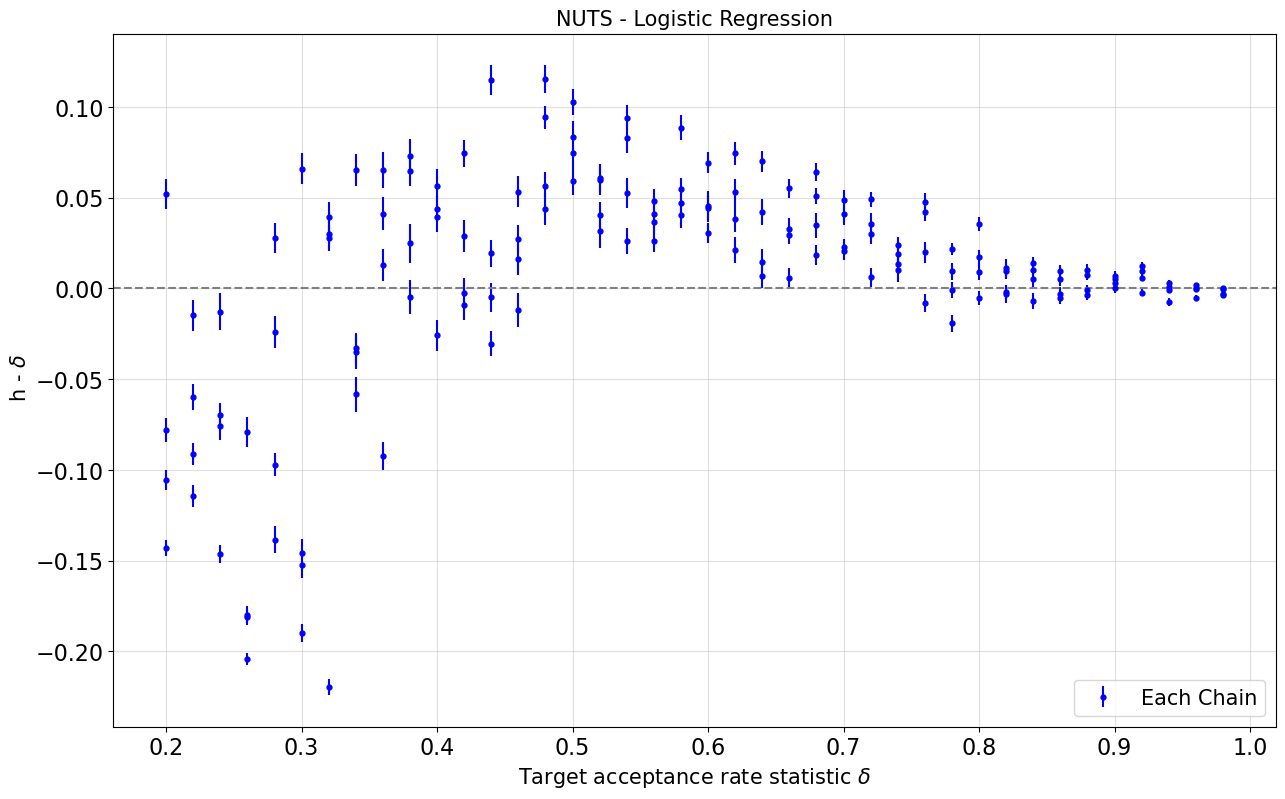

In [58]:
plt.rcParams.update({'font.size': 16})

repeated_X = [ val for val in accept_rate_list for _ in range(CHAINS) ]

# plot with errorbars
fig, ax = plt.subplots(figsize=(15,9))
plt.errorbar(x = repeated_X, y = all_diffs.flatten(), yerr = all_mcse.flatten(), ls="", fmt=".", ms=7, label="Each Chain", color="blue" )
plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.axhline(y=0.0, ls="--", color="gray")
plt.grid(alpha=0.4)
plt.show()

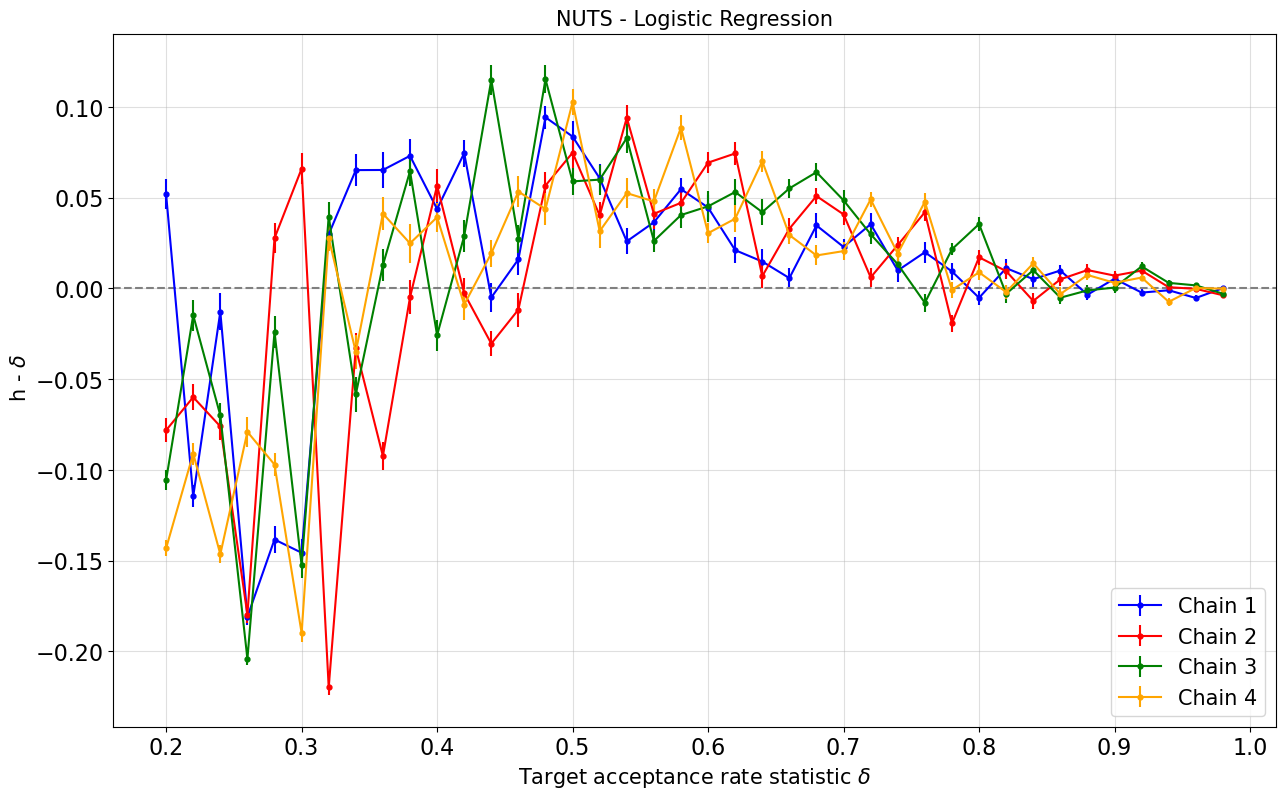

In [59]:
# or different color for each chain
colors = ["blue", "red", "green", "orange"]
fig, ax = plt.subplots(figsize=(15,9))
for c in range(CHAINS):
    ax.errorbar(x = accept_rate_list, y = all_diffs[:,c], yerr = all_mcse[:,c], ls="-", fmt=".", ms=7, label=f"Chain {c+1}", color=colors[c]
               )
plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.axhline(y=0.0, ls="--", color="gray")
plt.grid(alpha=0.4)
plt.show()

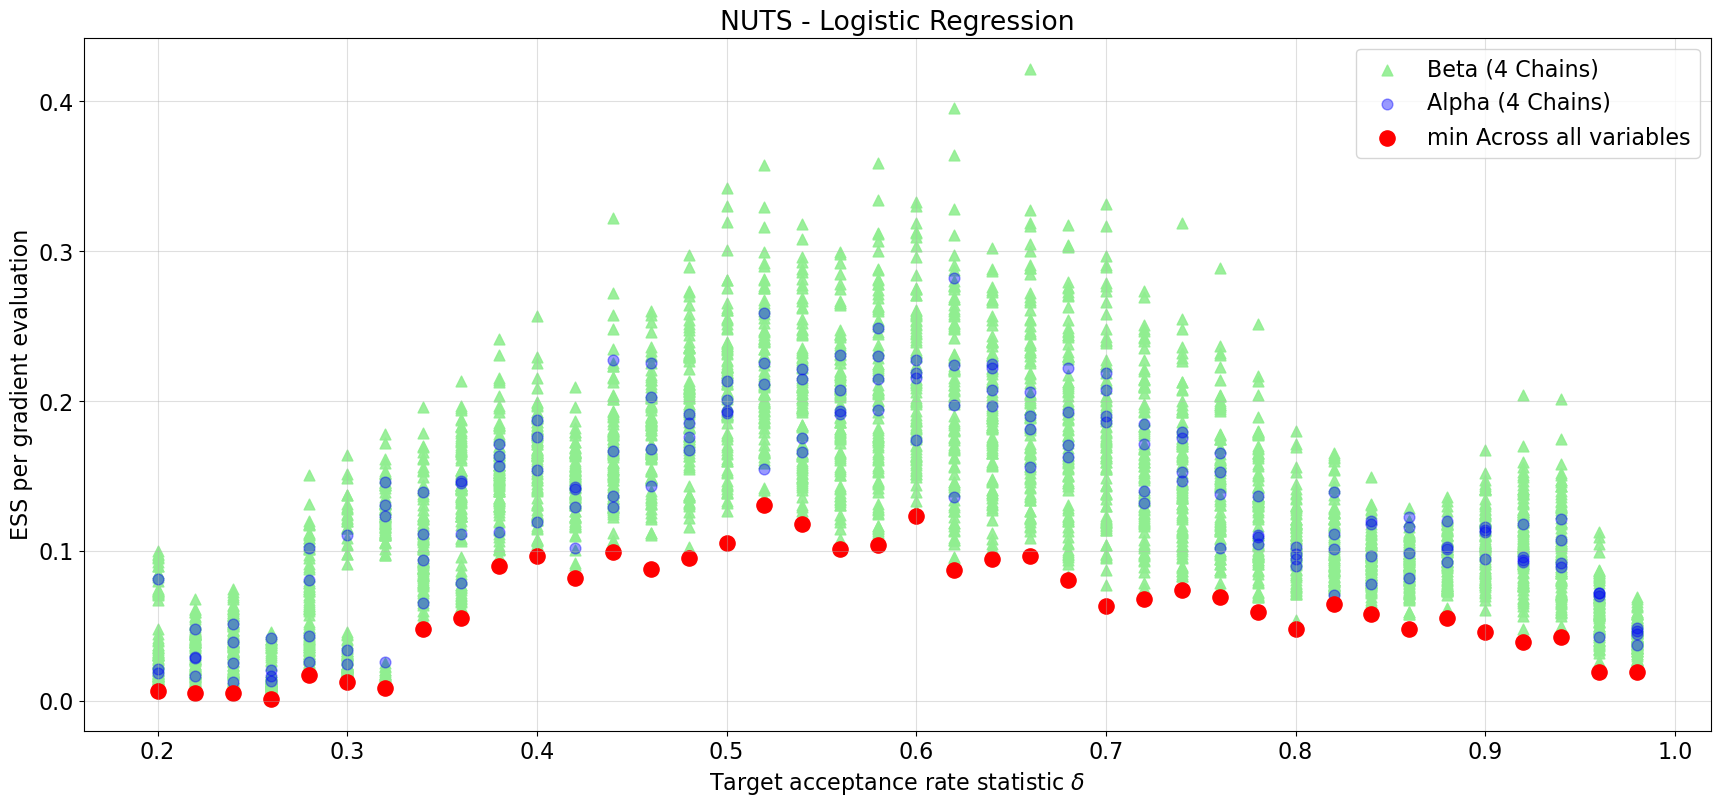

In [61]:
repeated_X = [ val for val in accept_rate_list for _ in range(CHAINS) ]

# plot with errorbars
fig, ax = plt.subplots(figsize=(21,9))
repeated_X_24 = [ val for val in accept_rate_list for _ in range(CHAINS*24) ]
plt.scatter(x = repeated_X_24, y = ESS_GRAD_EV_BETA, marker="^", label="Beta (4 Chains)", color="lightgreen", alpha = 0.9 , s = 60)
plt.scatter(x = repeated_X, y = ESS_GRAD_EV_ALPHA, marker="o", label="Alpha (4 Chains)", color="blue", alpha = 0.4, s = 60)
plt.scatter(x = accept_rate_list, y = ESS_GRAD_EV_SCALAR, marker="o", label=choice+" Across all variables", color="red", s = 120)

plt.xlabel(r"Target acceptance rate statistic $\delta$ ")
plt.ylabel("ESS per gradient evaluation")
plt.title("NUTS - Logistic Regression")
plt.legend(loc="upper right", fontsize=16)
plt.grid(alpha=0.4)
plt.show()